In [34]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

# Prep Clinical Trials

In [4]:
clin_entities_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_to_embeddings_ontologies/drug_disease_mapped_clinical.csv"
df_clin_entities = pd.read_csv(clin_entities_file)
df_clin_entities.head()

,nct_id,drug_term_umls_norm,drug_umls_termid,disease_term_mondo_norm,disease_mondo_termid
0,NCT00000307,Naltrexone,C0027360,alcohol-related disorders|alcoholic cocaine de...,MONDO:0021698|-1|MONDO:0005186
1,NCT00000333,Atropine|Benztropine|Benztropine|da reuptake i...,C0004259|C0005098|C0005098|-1,cocaine|cocaine dependence,-1|MONDO:0005186
2,NCT00000428,Amitriptyline|amitriptyline plus fluoxitine|fl...,C0002600|-1|-1|C0016365,fibromyalgia,MONDO:0005546
3,NCT00000439,depacon|Valproate Sodium|Valproate|Valproic Acid,-1|C0037567|C0080356|C0042291,alcohol abuse|bipolar alcoholics|bipolar disor...,MONDO:0002046|-1|MONDO:0004985|-1
4,NCT00001956,Ketorolac|Lidocaine|Midazolam|sedative,C0073631|C0023660|C0026056|-1,hyperalgesia|oral surgery|obsolete disorder in...,-1|-1|MONDO:0021668|-1


In [5]:
df_clin_entities.shape


(18609, 5)

In [9]:
clin_metadata_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_nct_docs_metadata_20240313.csv"
df_clin_metadata = pd.read_csv(clin_metadata_file)
df_clin_metadata = df_clin_metadata.drop_duplicates(subset=['nct_id'])

df_clin_metadata.head()

,nct_id,Neurological Disease,Disease Class,brief_title,study_official_title,brief_summary_description,start_date,completion_date,phase,study_type,overall_status,country_name,intervention_name,intervention_type
0,NCT03890861,"Dementia, Alzheimer Type",Neurodegenerative Diseases,Reducing African Americans' Alzheimer's Diseas...,Reducing African Americans' Alzheimer's Diseas...,The RAATE proposal is designed to determine th...,2019-08-09,2026-11-30,Not Applicable,Interventional,Recruiting,United States,Physical activity,Behavioral
6,NCT03060096,Depressive Symptoms,Psychiatry and Psychology Category,Stepped-Care Telehealth for Distress in Cancer...,Stepped-Care Telehealth for Distress in Cancer...,Mental health issues in post-treatment adult c...,2018-07-19,2023-12-31,Not Applicable,Interventional,Completed,United States,Severe Anxiety/depression: High Intensity Step...,Other
12,NCT04525742,Muscular Dystrophies,Neuromuscular Diseases,COVID-19 Pandemic and Parents of Disabled Chil...,COVID-19 Pandemic From the Perspective of Pare...,Pandemic period could affect the disabled chil...,2020-07-05,2020-09-15,Not Applicable,Interventional,Completed,Turkey,Difficulties lived by disabled children's pare...,Other
15,NCT02324634,Stroke,Central Nervous System Diseases,Early Electrical Stimulation to Prevent Compli...,Early Electrical Stimulation to the Wrist Exte...,Stroke is the largest cause of adult disabilit...,2015-06-01,2017-11-30,Not Applicable,Interventional,Unknown status,United Kingdom,NeuroTrac Rehab dual channel device,Device
18,NCT06036368,Essential Tremor,Central Nervous System Diseases,Study to Evaluate Safety and Efficacy of Peron...,"6-weeks, Open-label, Single-Site Study to Eval...","This is a 6-week exploratory clinical study, d...",2023-09-15,2024-06-30,Not Applicable,Interventional,Not yet recruiting,Czechia,Peroneal electrical transcutaneous neuromodula...,Device


In [10]:
df_clin_metadata.shape

(46376, 14)

In [67]:
df_clin_entities_metadata = df_clin_entities.merge(df_clin_metadata, on="nct_id", how="left")[['nct_id','drug_term_umls_norm','disease_term_mondo_norm', 'start_date', 'completion_date', 'overall_status', 'phase']]
df_clin_entities_metadata

,nct_id,drug_term_umls_norm,disease_term_mondo_norm,start_date,completion_date,overall_status,phase
0,NCT00000307,Naltrexone,alcohol-related disorders|alcoholic cocaine de...,2003-04-30,2007-04-30,Completed,Phase 2
1,NCT00000333,Atropine|Benztropine|Benztropine|da reuptake i...,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
2,NCT00000428,Amitriptyline|amitriptyline plus fluoxitine|fl...,fibromyalgia,2000-09-30,2004-03-31,Completed,Phase 4
3,NCT00000439,depacon|Valproate Sodium|Valproate|Valproic Acid,alcohol abuse|bipolar alcoholics|bipolar disor...,2000-10-31,2003-08-31,Completed,Phase 2
4,NCT00001956,Ketorolac|Lidocaine|Midazolam|sedative,hyperalgesia|oral surgery|obsolete disorder in...,2000-01-31,2005-02-28,Completed,Phase 2
...,...,...,...,...,...,...,...
18604,NCT06282640,Ergocalciferol|v|VITAMIN D,carpal tunnel syndrome|obsolete disorder invol...,2021-12-30,2022-08-30,Completed,Phase 4
18605,NCT06287502,HYDROXY-BETA-METHYLBUTYRATE|HYDROXY-BETA-METHY...,osteoporosis|obsolete sarcopenia,2022-09-09,2024-06-30,"Active, not recruiting",Not Applicable
18606,NCT06289335,Dexmedetomidine|Ondansetron|Saline,cesarean section|delirium|post-anesthetic shiv...,2020-08-05,2022-01-03,Completed,Phase 2
18607,NCT06292351,dmb-i|dmb-i (dimebon),Alzheimer disease|dementia,2023-12-27,2024-12-21,Recruiting,Phase 2/Phase 3


In [71]:
df_clin_entities_metadata_flat_drug = (
    df_clin_entities_metadata
    .assign(drug_term_umls_norm=df_clin_entities_metadata['drug_term_umls_norm'].astype(str).str.split("|"))
    .explode("drug_term_umls_norm")
)

In [72]:
df_clin_entities_metadata_flat_drug

,nct_id,drug_term_umls_norm,disease_term_mondo_norm,start_date,completion_date,overall_status,phase
0,NCT00000307,Naltrexone,alcohol-related disorders|alcoholic cocaine de...,2003-04-30,2007-04-30,Completed,Phase 2
1,NCT00000333,Atropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
1,NCT00000333,Benztropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
1,NCT00000333,Benztropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
1,NCT00000333,da reuptake inhibitor,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
...,...,...,...,...,...,...,...
18606,NCT06289335,Saline,cesarean section|delirium|post-anesthetic shiv...,2020-08-05,2022-01-03,Completed,Phase 2
18607,NCT06292351,dmb-i,Alzheimer disease|dementia,2023-12-27,2024-12-21,Recruiting,Phase 2/Phase 3
18607,NCT06292351,dmb-i (dimebon),Alzheimer disease|dementia,2023-12-27,2024-12-21,Recruiting,Phase 2/Phase 3
18608,NCT06293586,Acetaminophen,oculocutaneous albinism|oculocardiac reflex|st...,2023-12-01,2024-03-30,Recruiting,Not Applicable


In [73]:
df_clin_entities_metadata_flat_drug[df_clin_entities_metadata_flat_drug['drug_term_umls_norm'].str.contains("QUEtiapine") & df_clin_entities_metadata_flat_drug['phase'].str.contains("Phase 4")]

,nct_id,drug_term_umls_norm,disease_term_mondo_norm,start_date,completion_date,overall_status,phase
43,NCT00014001,QUEtiapine,schizophrenia,2000-12-31,2004-12-31,Completed,Phase 4
54,NCT00018668,QUEtiapine,depressive disorder|psychiatric disorder|motor...,2000-10-31,2004-09-30,Completed,Phase 4
121,NCT00034905,QUEtiapine,schizophrenia,2001-07-31,2002-09-30,Completed,Phase 4
173,NCT00043849,QUEtiapine,agitation|coexistent|dementia|Parkinson diseas...,2002-07-31,2005-06-30,Completed,Phase 4
189,NCT00044655,QUEtiapine,schizophrenia,2001-07-31,2009-03-31,Completed,Phase 4
...,...,...,...,...,...,...,...
10791,NCT02612948,QUEtiapine,"critically ill|critically ill,|delirium|high-r...",2013-11-30,2014-06-30,Completed,Phase 4
11427,NCT02845453,QUEtiapine,bipolar disorder|mood disorder|severe mood dys...,2017-01-20,2021-04-07,Completed,Phase 4
13174,NCT03568500,QUEtiapine,first episode psychosis|psychotic disorder|sch...,2018-05-21,2019-09-06,Completed,Phase 4
15187,NCT04446234,QUEtiapine,cardiotoxicity|schizophrenia,2021-05-31,2022-12-31,Unknown status,Phase 4


In [74]:
# Ensure date columns are in datetime format
df_clin_entities_metadata_flat_drug["start_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["start_date"], errors="coerce"
)
df_clin_entities_metadata_flat_drug["completion_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["completion_date"], errors="coerce"
)

# Compute duration in days
df_clin_entities_metadata_flat_drug["trial_duration_days"] = (
    df_clin_entities_metadata_flat_drug["completion_date"]
    - df_clin_entities_metadata_flat_drug["start_date"]
).dt.days

# Remove negative or invalid durations
df_clin_entities_metadata_flat_drug.loc[
    df_clin_entities_metadata_flat_drug["trial_duration_days"] < 0,
    "trial_duration_days"
] = np.nan

# Convert to years (rounded to 2 decimals)
df_clin_entities_metadata_flat_drug["trial_duration_years"] = (
    df_clin_entities_metadata_flat_drug["trial_duration_days"] / 365.25
).round(2)

In [75]:
df_clin_entities_metadata_flat_drug

,nct_id,drug_term_umls_norm,disease_term_mondo_norm,start_date,completion_date,overall_status,phase,trial_duration_days,trial_duration_years
0,NCT00000307,Naltrexone,alcohol-related disorders|alcoholic cocaine de...,2003-04-30,2007-04-30,Completed,Phase 2,1461.0,4.00
1,NCT00000333,Atropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2,699.0,1.91
1,NCT00000333,Benztropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2,699.0,1.91
1,NCT00000333,Benztropine,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2,699.0,1.91
1,NCT00000333,da reuptake inhibitor,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2,699.0,1.91
...,...,...,...,...,...,...,...,...,...
18606,NCT06289335,Saline,cesarean section|delirium|post-anesthetic shiv...,2020-08-05,2022-01-03,Completed,Phase 2,516.0,1.41
18607,NCT06292351,dmb-i,Alzheimer disease|dementia,2023-12-27,2024-12-21,Recruiting,Phase 2/Phase 3,360.0,0.99
18607,NCT06292351,dmb-i (dimebon),Alzheimer disease|dementia,2023-12-27,2024-12-21,Recruiting,Phase 2/Phase 3,360.0,0.99
18608,NCT06293586,Acetaminophen,oculocutaneous albinism|oculocardiac reflex|st...,2023-12-01,2024-03-30,Recruiting,Not Applicable,120.0,0.33


In [86]:
def phase_to_num(s: str) -> float:
    """
    Map phase strings (Arabic only) to numeric ranks:
      Not Applicable -> 0.0
      Early Phase 1 / Phase 0 -> 0.75
      Phase x        -> x.0
      Phase x/y      -> (min(x,y) + 0.5)
      Phase 2a/b     -> 2.0 (treat a/b as that phase)
    Unknown/missing -> NaN
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan
    t = s.strip()

    if re.search(r"not\s*applicable|observational", t, re.I):
        return 0.0
    if re.search(r"early\s*phase\s*1|phase\s*0", t, re.I):
        return 0.75

    # Extract all Arabic phase numbers present
    nums = [int(x) for x in re.findall(r"Phase\s*([0-4])(?:\s*[abAB])?", t, flags=re.I)]
    if len(nums) >= 2:
        a, b = sorted(nums[:2])
        return a + 0.5
    if len(nums) == 1:
        return float(nums[0])

    return np.nan

def summarize_trials_by_drug_simple(
    df: pd.DataFrame,
    drug_col: str = "drug_term_umls_norm",
    nct_col: str = "nct_id",
    date_col: str = "start_date",
    phase_col: str = "phase",
    duration_col: str = "trial_duration_years",
    status_col: str = "overall_status",
):
    """
    For each drug, return:
      - number of unique trials
      - min & max phase (with NCT + start year; min ignores 'Not Applicable')
      - median trial duration (years)
      - shortest (only among COMPLETED trials) & longest trial durations (years) with NCT IDs
    """

    # --- Prepare exploded dataset ---
    use_cols = [c for c in [nct_col, drug_col, date_col, phase_col, duration_col, status_col] if c in df.columns]
    w = df[use_cols].copy()

    # explode pipe-separated drugs
    w = w[w[drug_col].notna()].copy()
    w[drug_col] = w[drug_col].astype(str).str.split("|")
    w = w.explode(drug_col)
    w[drug_col] = w[drug_col].astype(str).str.strip()
    w = w[(w[drug_col].notna()) & (w[drug_col] != "") & (w[drug_col].str.lower() != "nan")].copy()

    # parse dates & helpers
    w[date_col] = pd.to_datetime(w[date_col], errors="coerce")
    w["start_year"] = w[date_col].dt.year
    w["phase_num"] = w[phase_col].apply(phase_to_num)

    # --- Aggregates ---
    n_trials = w.groupby(drug_col)[nct_col].nunique().rename("n_unique_trials")
    median_duration = (
        w.groupby(drug_col)[duration_col].median().rename("median_trial_duration_years")
        if duration_col in w.columns else pd.Series(dtype=float, name="median_trial_duration_years")
    )

    # --- Shortest (Completed) trial ---
    if duration_col in w.columns:
        completed_mask = w[status_col].str.lower().eq("completed") if status_col in w.columns else pd.Series(True, index=w.index)
        w_completed = w[completed_mask & w[duration_col].notna()]

        shortest_info = (
            w_completed
            .sort_values([drug_col, duration_col, date_col])
            .drop_duplicates(subset=[drug_col], keep="first")
            [[drug_col, nct_col, duration_col]]
            .rename(columns={
                nct_col: "shortest_trial_nct_id",
                duration_col: "shortest_trial_years"
            })
        )

        # --- Longest trial (all statuses) ---
        longest_info = (
            w.dropna(subset=[duration_col])
            .sort_values([drug_col, duration_col, date_col], ascending=[True, False, True])
            .drop_duplicates(subset=[drug_col], keep="first")
            [[drug_col, nct_col, duration_col]]
            .rename(columns={
                nct_col: "longest_trial_nct_id",
                duration_col: "longest_trial_years"
            })
        )
    else:
        shortest_info = pd.DataFrame(columns=[drug_col, "shortest_trial_nct_id", "shortest_trial_years"])
        longest_info  = pd.DataFrame(columns=[drug_col, "longest_trial_nct_id",  "longest_trial_years"])

    # --- MAX phase (earliest start if tie) ---
    valid_max = w[w["phase_num"].notna()].copy()
    max_info = (
        valid_max.loc[valid_max.groupby(drug_col)["phase_num"].transform("max").eq(valid_max["phase_num"])]
        .sort_values([drug_col, date_col])
        .drop_duplicates(subset=[drug_col])
        [[drug_col, nct_col, phase_col, "start_year"]]
        .rename(columns={
            nct_col: "max_phase_nct_id",
            phase_col: "max_phase",
            "start_year": "max_phase_start_year"
        })
    )

    # --- MIN phase (ignore ≤0 / Not Applicable) ---
    valid_min = w[(w["phase_num"].notna()) & (w["phase_num"] > 0.0)].copy()
    min_info = (
        valid_min.loc[valid_min.groupby(drug_col)["phase_num"].transform("min").eq(valid_min["phase_num"])]
        .sort_values([drug_col, date_col])
        .drop_duplicates(subset=[drug_col])
        [[drug_col, nct_col, phase_col, "start_year"]]
        .rename(columns={
            nct_col: "min_phase_nct_id",
            phase_col: "min_phase",
            "start_year": "min_phase_start_year"
        })
    )

    # --- Combine everything ---
    out = (
        n_trials.to_frame()
        .join(median_duration, how="left")
        .reset_index()
        .merge(min_info, on=drug_col, how="left")
        .merge(max_info, on=drug_col, how="left")
        .merge(shortest_info, on=drug_col, how="left")
        .merge(longest_info, on=drug_col, how="left")
        .rename(columns={drug_col: "drug_term_umls_norm"})
        .sort_values(["max_phase_start_year", "max_phase", "n_unique_trials"],
                     ascending=[True, False, False],
                     na_position="last")
    )

    # Round durations for nice display
    for c in ["median_trial_duration_years", "shortest_trial_years", "longest_trial_years"]:
        if c in out.columns:
            out[c] = out[c].astype(float).round(2)

    return out

In [87]:
clinical_drug_summary = summarize_trials_by_drug_simple(df_clin_entities_metadata_flat_drug)
clinical_drug_summary.head()

,drug_term_umls_norm,n_unique_trials,median_trial_duration_years,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
2951,Risperidone,326,2.24,NCT03790085,Early Phase 1,2018.0,NCT00469664,Phase 4,2000,NCT00645502,0.08,NCT02535156,12.00
2533,OLANZapine,257,2.41,NCT03790085,Early Phase 1,2018.0,NCT00469664,Phase 4,2000,NCT02804568,0.17,NCT00512070,18.42
701,ARIPiprazole,233,2.54,NCT03790085,Early Phase 1,2018.0,NCT00469664,Phase 4,2000,NCT01552772,0.25,NCT00320671,10.00
2851,QUEtiapine,215,2.33,NCT04280965,Early Phase 1,2019.0,NCT00469664,Phase 4,2000,NCT05793632,0.12,NCT00297947,9.83
7000,donepezil,170,2.13,NCT01024660,Early Phase 1,2009.0,NCT00267163,Phase 4,2000,NCT01042314,0.24,NCT03073876,15.12


<Axes: >

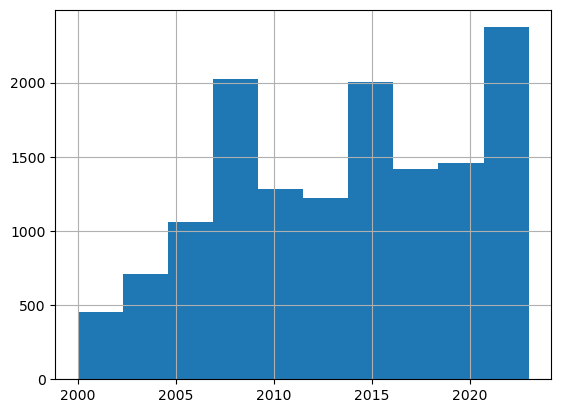

In [77]:
clinical_drug_summary.min_phase_start_year.hist()

<Axes: >

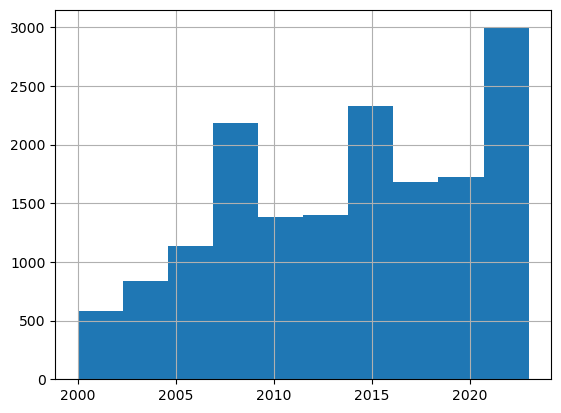

In [78]:
clinical_drug_summary.max_phase_start_year.hist()

In [85]:
clinical_drug_summary.to_csv("out/all_drugs_clinical_min_max_phase.csv")

# Prep Preclinical Articles

In [111]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations.csv"
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
preclin_dataset


/sctmp/sdonev/ipykernel_1836888/1038636441.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin|Pentobarbital,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled
4,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,beta-adrenergic receptor blocking agent|Nadolo...,"cat, dog",male,not reported,Mongrel,not reported,"Molecular & Cellular, Physiology",unlabeled
...,...,...,...,...,...,...,...,...,...,...,...
340375,38129421,Active polypeptide MDANP protect against necro...,perinatal necrotizing enterocolitis,mdanp,mouse,female,not reported,C57BL/6,not reported,"Histology, Molecular & Cellular",China
340376,38129863,Hyperglycemia-induced STING signaling activati...,diabetes mellitus|obsolete diabetic angiopathy...,c-176|vadimezan,"mouse, rat",male,not reported,C57BL/6,not reported,"Histology, Molecular & Cellular",China
340377,38129872,"In diabetic male Wistar rats, quercetin-conjug...",diabetes mellitus|cognitive disorder,Quercetin,rat,male,adult,Wistar,40.0,Molecular & Cellular,Iran
340378,38129888,Amlodipine alleviates renal ischemia/reperfusi...,acute kidney failure,Amlodipine,rat,male,not reported,Wistar,18.0,Molecular & Cellular,Iran


In [112]:
preclin_dataset = (
    preclin_dataset
    .assign(drug_term_umls_norm=preclin_dataset['drug_term_umls_norm'].astype(str).str.split("|"))
    .explode("drug_term_umls_norm")
)
preclin_dataset

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled
...,...,...,...,...,...,...,...,...,...,...,...
340376,38129863,Hyperglycemia-induced STING signaling activati...,diabetes mellitus|obsolete diabetic angiopathy...,c-176,"mouse, rat",male,not reported,C57BL/6,not reported,"Histology, Molecular & Cellular",China
340376,38129863,Hyperglycemia-induced STING signaling activati...,diabetes mellitus|obsolete diabetic angiopathy...,vadimezan,"mouse, rat",male,not reported,C57BL/6,not reported,"Histology, Molecular & Cellular",China
340377,38129872,"In diabetic male Wistar rats, quercetin-conjug...",diabetes mellitus|cognitive disorder,Quercetin,rat,male,adult,Wistar,40.0,Molecular & Cellular,Iran
340378,38129888,Amlodipine alleviates renal ischemia/reperfusi...,acute kidney failure,Amlodipine,rat,male,not reported,Wistar,18.0,Molecular & Cellular,Iran


In [113]:
preclin_dataset_to_clinical = preclin_dataset.merge(clinical_drug_summary, on="drug_term_umls_norm", how="left")
preclin_dataset_to_clinical = preclin_dataset_to_clinical[preclin_dataset_to_clinical["n_unique_trials"].notna()]

In [114]:
preclin_dataset_to_clinical.PMID.nunique()

195315

In [115]:
def classify_translation(max_phase):
    if max_phase == "Phase 4":
        return "approved"
    else:
        return "failed"


preclin_dataset_to_clinical['study_classification'] = preclin_dataset_to_clinical['max_phase'].apply(lambda x:classify_translation(x))

In [116]:
preclin_dataset_to_clinical.shape

(339072, 24)

In [117]:
preclin_dataset_to_clinical.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,...,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,rat,male,not reported,Sprague-Dawley,not reported,Histology,...,Early Phase 1,2022.0,NCT04858139,Phase 2,2021.0,NCT01455376,0.25,NCT01573507,5.72,failed
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,...,Early Phase 1,2016.0,NCT02495883,Phase 4,2013.0,NCT01054859,0.00,NCT00816231,13.12,approved
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,rat,not-reported,not reported,not reported,2.0,not reported,...,Early Phase 1,2004.0,NCT00146237,Phase 4,2003.0,NCT02283827,0.16,NCT04573803,7.00,approved
4,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,rat,not-reported,not reported,not reported,2.0,not reported,...,Phase 1/Phase 2,2004.0,NCT00622570,Phase 3,2002.0,NaN,NaN,NCT00622570,5.59,failed
8,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,Propranolol,"cat, dog",male,not reported,Mongrel,not reported,"Molecular & Cellular, Physiology",...,Early Phase 1,2014.0,NCT00060866,Phase 4,2003.0,NCT00093860,0.41,NCT01988883,10.17,approved


In [118]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'title', 'disease_term_mondo_norm', 'drug_term_umls_norm',
       'animal_species', 'animal_sex', 'animal_age', 'animal_strain',
       'animal_number', 'assay_type', 'first_author_country',
       'n_unique_trials', 'median_trial_duration_years', 'min_phase_nct_id',
       'min_phase', 'min_phase_start_year', 'max_phase_nct_id', 'max_phase',
       'max_phase_start_year', 'shortest_trial_nct_id', 'shortest_trial_years',
       'longest_trial_nct_id', 'longest_trial_years', 'study_classification'],
      dtype='object')

In [133]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq

In [135]:
total_unique, freq = count_unique_from_pipe_column(preclin_dataset_to_clinical, "drug_term_umls_norm")

In [136]:
total_unique

4357

# Translation stats

In [131]:
def split_drug_rows(df_in, drug_col, min_length=0):
    rows = []
    for _, row in df_in.iterrows():
        if pd.isna(row[drug_col]):
            print(f"ROW EMPTY {row}")
            continue
        for drug in _splitter.split(row[drug_col]):
            drug = drug.strip()
            if len(drug) >= min_length:
                r = row.copy()
                r['single_drug'] = drug
                rows.append(r)
    return pd.DataFrame(rows)
    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved')].copy()
    non_approved_long = split_drug_rows(non_approved_studies, drug_col)
    aggregate_stats_non_approved = get_heterogeneity_stats(non_approved_long, agg_dict, drug_col_name="single_drug")

    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved')].copy()
    approved_long = split_drug_rows(approved_matches, drug_col)
    aggregate_stats_approved = get_heterogeneity_stats(approved_long, agg_dict, drug_col_name=drug_col)

    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })
    
    # Optional: tidy row order
    order = [
        'n_drugs_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        #'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        #'%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df

def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_drugs_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        elif 'female' in t:    out.add('female')
        elif 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''

_splitter = re.compile(r'[|,]')

In [132]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df = compute_experimental_chars(preclin_dataset_to_clinical, agg_dict, drug_col="drug_term_umls_norm")

comparison_df

,Approved,Non-approved
n_drugs_in_table,1285,3118
total_number_of_studies,125362,100700
tested_in_both_sexes,838 (65.2%),1553 (49.8%)
tested_in_>=2_species,1085 (84.4%),2257 (72.4%)
tested_in_>=2_strains,1142 (88.9%),2540 (81.5%)
tested_with_>=2_outcomes,1219 (94.9%),2857 (91.6%)
tested_in_>=2_countries,1120 (87.2%),2340 (75.0%)
